# Exercises XP Gold - K-means from Scratch


## Task 1 - Load and Visualize the Dataset



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import pandas as pd

mat_path = 'ex7data2.mat'
data = loadmat(mat_path)

X = data['X']
print('Shape of X:', X.shape)

print('\nFirst 5 rows of data:')
print(X[:5])

print(f'\nDataset statistics:')
print(f'Number of data points: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'X range: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]')
print(f'Y range: [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]')

Shape of X: (300, 2)

First 5 rows of data:
[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]

Dataset statistics:
Number of data points: 300
Number of features: 2
X range: [-0.25, 8.20]
Y range: [0.21, 5.78]


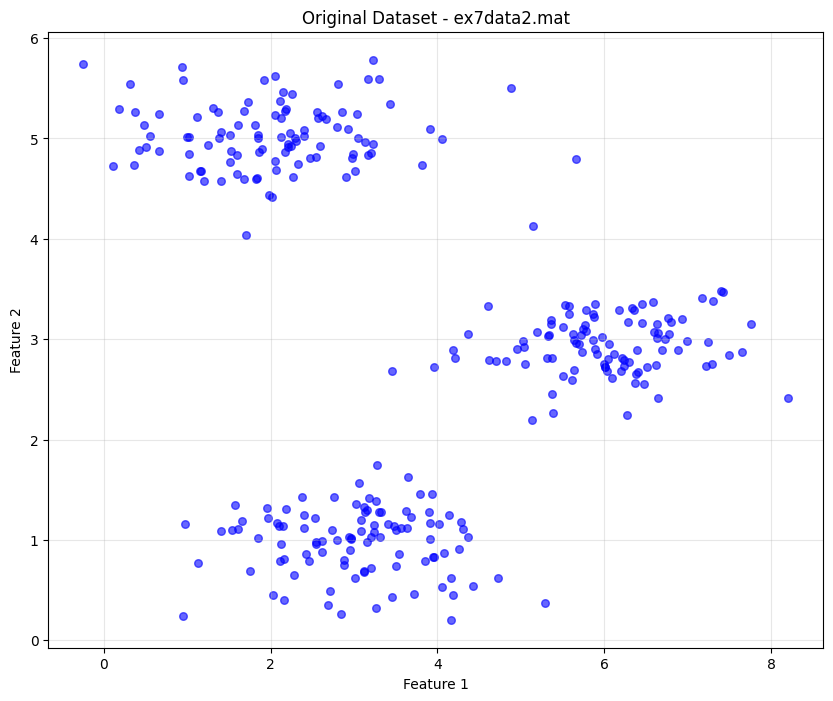

Dataset loaded and visualized successfully!


In [2]:
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=30, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Dataset - ex7data2.mat')
plt.grid(True, alpha=0.3)
plt.show()

print("Dataset loaded and visualized successfully!")

## Task 2 - Finding Closest Centroids

Implement find_closest_centroids(X, centroids).

- Input: X shape (m, n), centroids shape (K, n)
- Output: idx shape (m,), integer cluster index in [0, K-1] for each point
- Use squared Euclidean distances
- Test with initial centroids = np.array([[3, 3], [6, 2], [8, 5]]) and print the first three indices

Initial centroids:
[[3. 3.]
 [6. 2.]
 [8. 5.]]

First three closest centroid indices: [0 2 1]
Shape of idx: (300,)


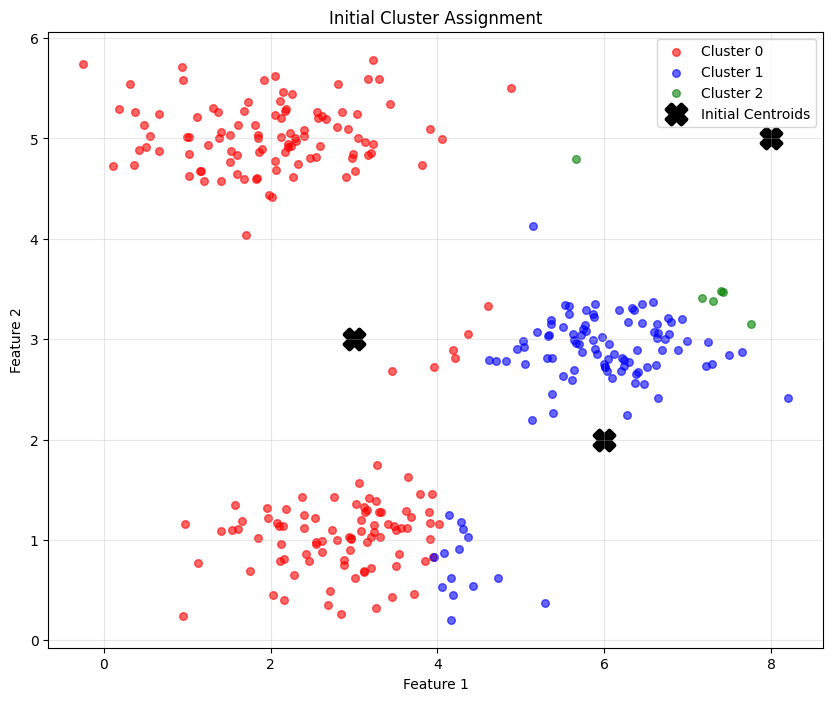

In [3]:
def find_closest_centroids(X, centroids):
    m = X.shape[0]
    K = centroids.shape[0]
    
    X_expanded = X[:, np.newaxis, :] 
    centroids_expanded = centroids[np.newaxis, :, :]  
    
    diff = X_expanded - centroids_expanded  
    distances = np.sum(diff**2, axis=2)  
    
    idx = np.argmin(distances, axis=1)  
    
    return idx

init_centroids = np.array([[3, 3], [6, 2], [8, 5]], dtype=float)
print("Initial centroids:")
print(init_centroids)

idx = find_closest_centroids(X, init_centroids)
print(f"\nFirst three closest centroid indices: {idx[:3]}")
print(f"Shape of idx: {idx.shape}")

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
for k in range(3):
    mask = idx == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=30, alpha=0.6, label=f'Cluster {k}')

plt.scatter(init_centroids[:, 0], init_centroids[:, 1], 
           c='black', marker='X', s=200, linewidths=3, label='Initial Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Initial Cluster Assignment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 3 - Computing Centroids



Original centroids:
[[3. 3.]
 [6. 2.]
 [8. 5.]]

New centroids after one iteration:
[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]

Centroid movement:
Centroid 0 moved 0.5931 units
Centroid 1 moved 0.6605 units
Centroid 2 moved 1.6398 units


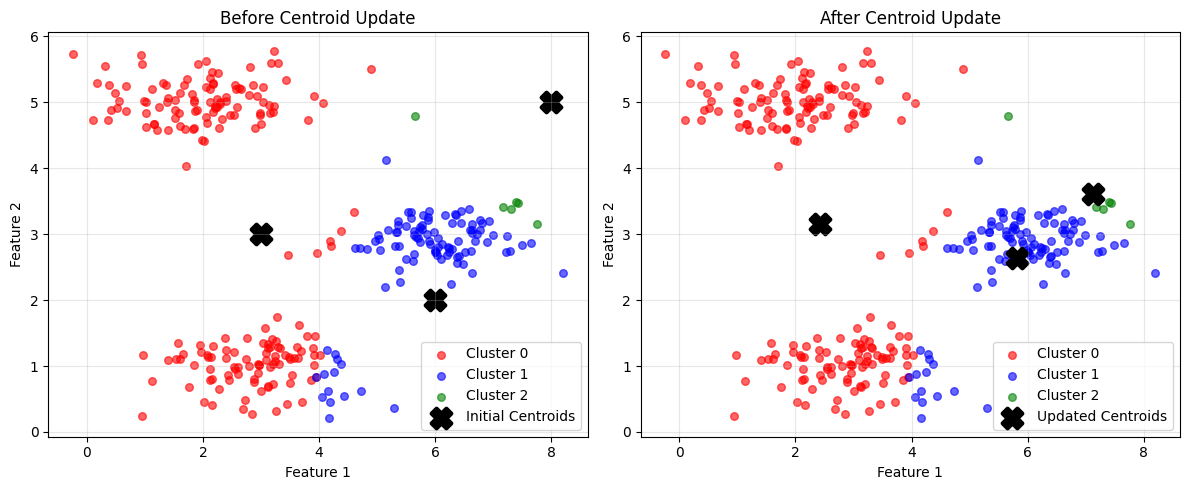

In [4]:
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    new_centroids = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    
    for k in range(K):
        pts = X[idx == k]
        
        if pts.shape[0] == 0:
            random_idx = rng.integers(0, m)
            new_centroids[k] = X[random_idx]
            print(f"Warning: Cluster {k} is empty, reinitializing with random point")
        else:
            new_centroids[k] = np.mean(pts, axis=0)
    
    return new_centroids

idx_test = find_closest_centroids(X, init_centroids)
new_centroids = compute_centroids(X, idx_test, K=3)

print("Original centroids:")
print(init_centroids)
print("\nNew centroids after one iteration:")
print(new_centroids)

print(f"\nCentroid movement:")
for k in range(3):
    movement = np.linalg.norm(new_centroids[k] - init_centroids[k])
    print(f"Centroid {k} moved {movement:.4f} units")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for k in range(3):
    mask = idx_test == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=30, alpha=0.6, label=f'Cluster {k}')

plt.scatter(init_centroids[:, 0], init_centroids[:, 1], 
           c='black', marker='X', s=200, linewidths=3, label='Initial Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Before Centroid Update')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for k in range(3):
    mask = idx_test == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=30, alpha=0.6, label=f'Cluster {k}')

plt.scatter(new_centroids[:, 0], new_centroids[:, 1], 
           c='black', marker='X', s=200, linewidths=3, label='Updated Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('After Centroid Update')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 4 - Running K-means



Running K-means for 10 iterations...
Iteration 1/10
Iteration 2/10
  Average centroid movement: 0.372191
Iteration 3/10
  Average centroid movement: 0.356399
Iteration 4/10
  Average centroid movement: 0.697465
Iteration 5/10
  Average centroid movement: 0.692651
Iteration 6/10
  Average centroid movement: 0.074748
Iteration 7/10
  Average centroid movement: 0.000000
Iteration 8/10
  Average centroid movement: 0.000000
Iteration 9/10
  Average centroid movement: 0.000000
Iteration 10/10
  Average centroid movement: 0.000000
K-means completed!

Final centroids:
[[1.95399466 5.02557006]
 [3.04367119 1.01541041]
 [6.03366736 3.00052511]]


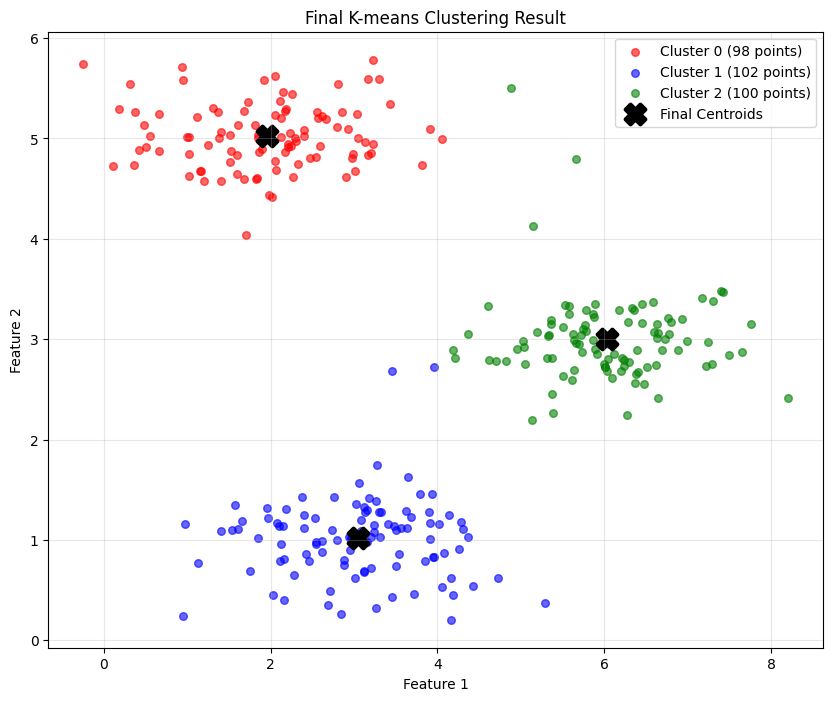

In [5]:
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]
    centroids = init_centroids.copy().astype(float)
    history = [centroids.copy()]
    idx = None
    
    print(f"Running K-means for {max_iters} iterations...")
    
    for it in range(max_iters):
        print(f"Iteration {it + 1}/{max_iters}")
        
        idx = find_closest_centroids(X, centroids)
        
        centroids = compute_centroids(X, idx, K, rng)
        
        history.append(centroids.copy())
        
        if it > 0:
            movement = np.mean([np.linalg.norm(history[-1][k] - history[-2][k]) 
                              for k in range(K)])
            print(f"  Average centroid movement: {movement:.6f}")
    
    print("K-means completed!")
    return centroids, idx, history

final_centroids, final_idx, hist = run_k_means(X, init_centroids, max_iters=10)

print(f"\nFinal centroids:")
print(final_centroids)

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']

for k in range(3):
    mask = final_idx == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=30, alpha=0.6, 
               label=f'Cluster {k} ({np.sum(mask)} points)')

plt.scatter(final_centroids[:, 0], final_centroids[:, 1], 
           c='black', marker='X', s=200, linewidths=3, label='Final Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Final K-means Clustering Result')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

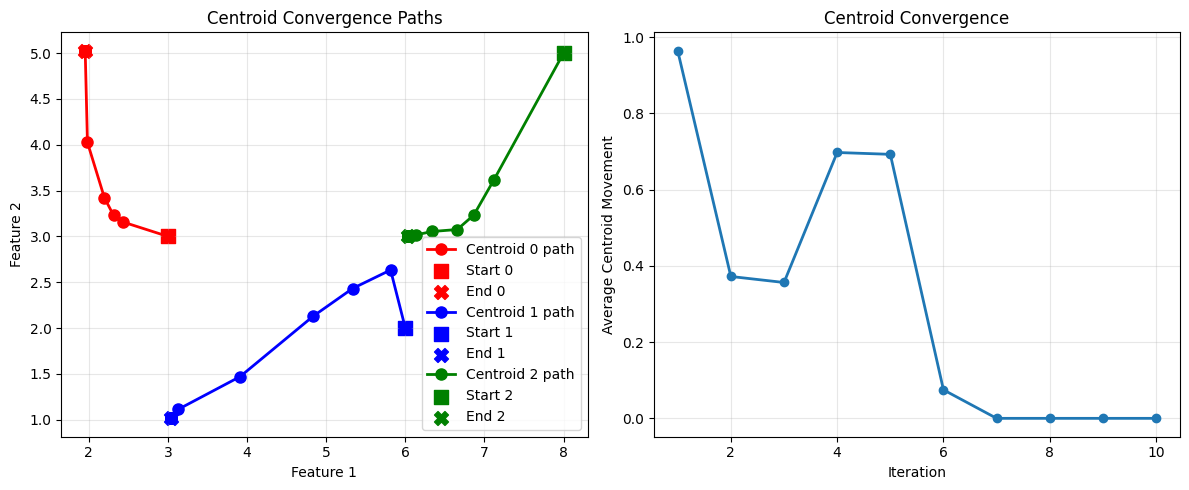

Convergence analysis:
Initial centroid positions: [[3. 3.]
 [6. 2.]
 [8. 5.]]
Final centroid positions: [[1.95399466 5.02557006]
 [3.04367119 1.01541041]
 [6.03366736 3.00052511]]
Total movement from start to end:
  Centroid 0: 2.2797 units
  Centroid 1: 3.1160 units
  Centroid 2: 2.8043 units


In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for k in range(3):
    centroid_path = np.array([hist[i][k] for i in range(len(hist))])
    plt.plot(centroid_path[:, 0], centroid_path[:, 1], 'o-', 
             color=colors[k], linewidth=2, markersize=8, 
             label=f'Centroid {k} path')
    plt.scatter(centroid_path[0, 0], centroid_path[0, 1], 
               color=colors[k], marker='s', s=100, 
               label=f'Start {k}')
    plt.scatter(centroid_path[-1, 0], centroid_path[-1, 1], 
               color=colors[k], marker='X', s=100, 
               label=f'End {k}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Centroid Convergence Paths')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
movements = []
for i in range(1, len(hist)):
    movement = np.mean([np.linalg.norm(hist[i][k] - hist[i-1][k]) 
                       for k in range(3)])
    movements.append(movement)

plt.plot(range(1, len(hist)), movements, 'o-', linewidth=2, markersize=6)
plt.xlabel('Iteration')
plt.ylabel('Average Centroid Movement')
plt.title('Centroid Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Convergence analysis:")
print(f"Initial centroid positions: {init_centroids}")
print(f"Final centroid positions: {final_centroids}")
print(f"Total movement from start to end:")
for k in range(3):
    total_movement = np.linalg.norm(final_centroids[k] - init_centroids[k])
    print(f"  Centroid {k}: {total_movement:.4f} units")

## Task 5 - Initializing Centroids



Testing random centroid initialization:

Random initialization 1:
[[2.1159935  0.7930365 ]
 [4.1590816  0.61720733]
 [3.20360621 0.7222149 ]]

Random initialization 2:
[[5.78769095 3.29255127]
 [3.91596068 1.01225774]
 [7.65503226 2.87095628]]

Random initialization 3:
[[1.36678395 5.26161095]
 [6.99198434 2.98706729]
 [2.02358978 0.44771614]]

Testing with different random seeds:

Seed 0:
[[2.94294356 1.02825076]
 [2.95818429 1.01887096]
 [6.92721968 3.19960026]]

Seed 1:
[[2.95818429 1.01887096]
 [3.7875723  1.45442904]
 [5.37293912 2.81684776]]

Seed 2:
[[0.47647355 5.13535977]
 [2.06995345 4.6846713 ]
 [6.03762833 2.68303512]]
Running K-means for 5 iterations...
Iteration 1/5
Iteration 2/5
  Average centroid movement: 0.677181
Iteration 3/5
  Average centroid movement: 0.000000
Iteration 4/5
  Average centroid movement: 0.000000
Iteration 5/5
  Average centroid movement: 0.000000
K-means completed!
Running K-means for 5 iterations...
Iteration 1/5
Iteration 2/5
  Average centroid m

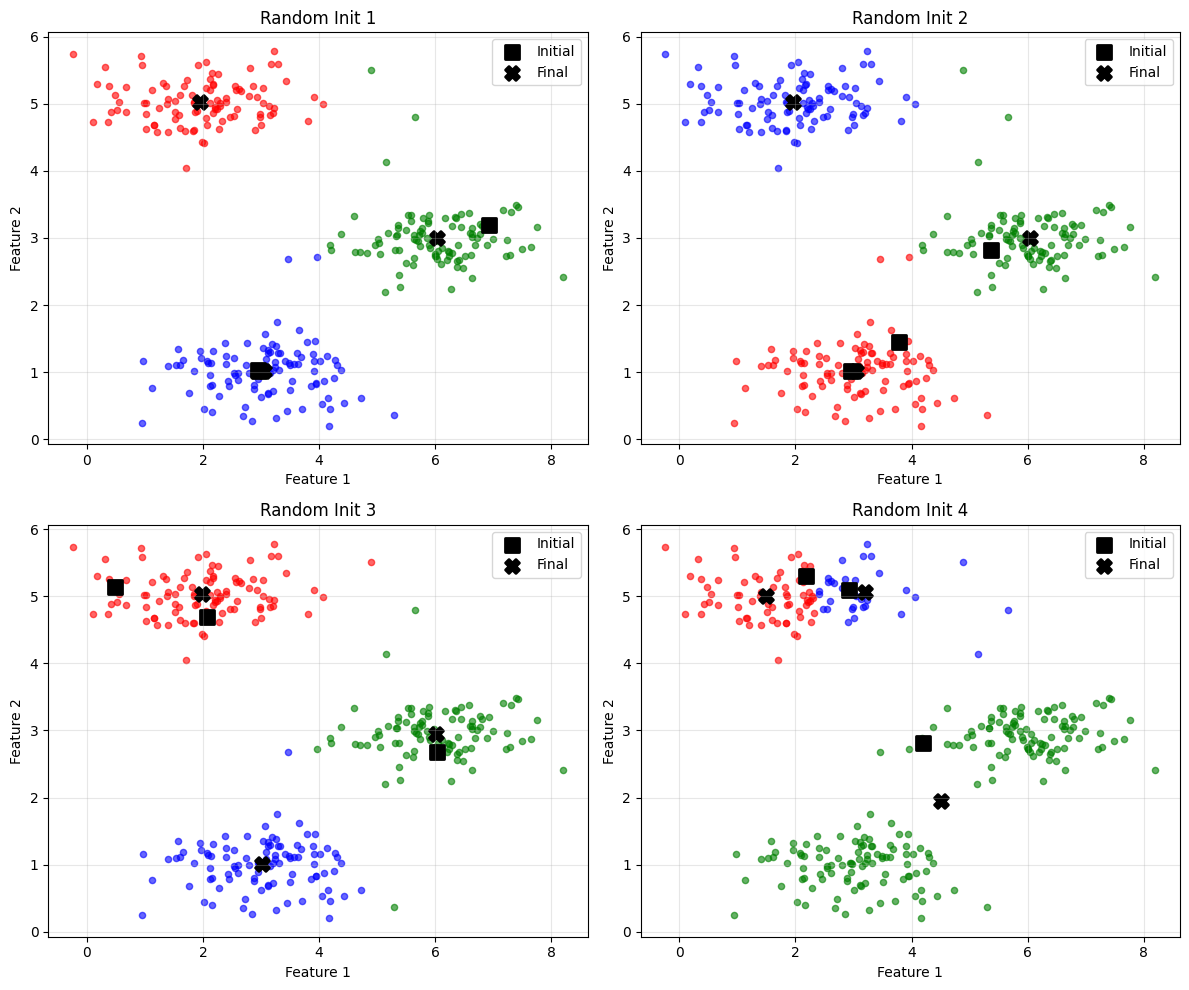

In [7]:
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    
    idx = rng.choice(m, size=K, replace=False)
    
    return X[idx].astype(float)

print("Testing random centroid initialization:")
for i in range(3):
    random_centroids = init_centroids(X, 3)
    print(f"\nRandom initialization {i+1}:")
    print(random_centroids)

print("\nTesting with different random seeds:")
for seed in range(3):
    rng = np.random.default_rng(seed)
    random_centroids = init_centroids(X, 3, rng)
    print(f"\nSeed {seed}:")
    print(random_centroids)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i in range(4):
    rng = np.random.default_rng(i)
    random_centroids = init_centroids(X, 3, rng)
    
    final_c, final_i, _ = run_k_means(X, random_centroids, max_iters=5, rng=rng)
    
    ax = axes[i]
    colors = ['red', 'blue', 'green']
    
    for k in range(3):
        mask = final_i == k
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=20, alpha=0.6)
    
    ax.scatter(random_centroids[:, 0], random_centroids[:, 1], 
              c='black', marker='s', s=100, linewidths=2, 
              label='Initial')
    ax.scatter(final_c[:, 0], final_c[:, 1], 
              c='black', marker='X', s=100, linewidths=2, 
              label='Final')
    
    ax.set_title(f'Random Init {i+1}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 6 - Multiple Initializations and Evaluation


Inertia for our previous result: 266.6585

Running K-means with multiple random initializations...

Seed 0:
Running K-means for 10 iterations...
Iteration 1/10
Iteration 2/10
  Average centroid movement: 0.677181
Iteration 3/10
  Average centroid movement: 0.000000
Iteration 4/10
  Average centroid movement: 0.000000
Iteration 5/10
  Average centroid movement: 0.000000
Iteration 6/10
  Average centroid movement: 0.000000
Iteration 7/10
  Average centroid movement: 0.000000
Iteration 8/10
  Average centroid movement: 0.000000
Iteration 9/10
  Average centroid movement: 0.000000
Iteration 10/10
  Average centroid movement: 0.000000
K-means completed!
  Inertia: 266.6585
  *** New best result! ***

Seed 1:
Running K-means for 10 iterations...
Iteration 1/10
Iteration 2/10
  Average centroid movement: 0.994966
Iteration 3/10
  Average centroid movement: 0.731741
Iteration 4/10
  Average centroid movement: 0.043599
Iteration 5/10
  Average centroid movement: 0.000000
Iteration 6/10
  Averag

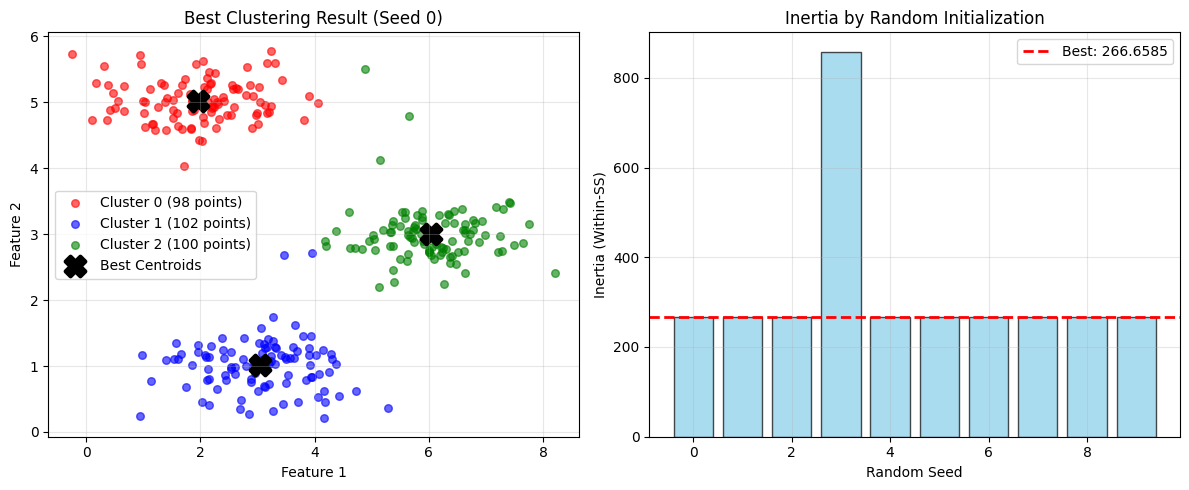

In [8]:
def withinss(X, centroids, idx):
    total_ss = 0.0
    K = centroids.shape[0]
    
    for k in range(K):
        cluster_points = X[idx == k]
        
        if len(cluster_points) > 0:
            diffs = cluster_points - centroids[k]
            cluster_ss = np.sum(diffs * diffs)
            total_ss += cluster_ss
    
    return float(total_ss)

test_inertia = withinss(X, final_centroids, final_idx)
print(f"Inertia for our previous result: {test_inertia:.4f}")

print(f"\nRunning K-means with multiple random initializations...")
print("=" * 60)

best = {'score': np.inf, 'centroids': None, 'idx': None, 'seed': None}
results = []

for seed in range(10):
    print(f"\nSeed {seed}:")
    rng = np.random.default_rng(seed)
    c0 = init_centroids(X, 3, rng)
    cF, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)
    s = withinss(X, cF, idxF)
    
    results.append({
        'seed': seed,
        'inertia': s,
        'centroids': cF,
        'idx': idxF
    })
    
    print(f"  Inertia: {s:.4f}")
    
    if s < best['score']:
        best = {'score': s, 'centroids': cF, 'idx': idxF, 'seed': seed}
        print(f"  *** New best result! ***")

print(f"\nBest inertia: {best['score']:.4f} (from seed {best['seed']})")

print(f"\nComparison of all runs:")
print("Seed | Inertia")
print("-" * 15)
for result in results:
    marker = " *" if result['seed'] == best['seed'] else ""
    print(f"{result['seed']:4d} | {result['inertia']:8.4f}{marker}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for k in range(3):
    mask = best['idx'] == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=30, alpha=0.6, 
               label=f'Cluster {k} ({np.sum(mask)} points)')

plt.scatter(best['centroids'][:, 0], best['centroids'][:, 1], 
           c='black', marker='X', s=200, linewidths=3, label='Best Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Best Clustering Result (Seed {best["seed"]})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
inertias = [r['inertia'] for r in results]
seeds = [r['seed'] for r in results]
plt.bar(seeds, inertias, alpha=0.7, color='skyblue', edgecolor='black')
plt.axhline(y=best['score'], color='red', linestyle='--', linewidth=2, 
           label=f'Best: {best["score"]:.4f}')
plt.xlabel('Random Seed')
plt.ylabel('Inertia (Within-SS)')
plt.title('Inertia by Random Initialization')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
print(f"\nCreating CSV file with best clustering assignments...")

data_for_csv = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1], 
    'cluster': best['idx']
})

csv_filename = 'kmeans_assignments.csv'
data_for_csv.to_csv(csv_filename, index=False)
print(f"Saved clustering assignments to '{csv_filename}'")

print(f"\nFirst 10 rows of the CSV file:")
print(data_for_csv.head(10))

print(f"\nCluster Statistics:")
print("=" * 30)
for k in range(3):
    cluster_data = data_for_csv[data_for_csv['cluster'] == k]
    print(f"Cluster {k}:")
    print(f"  Size: {len(cluster_data)} points")
    print(f"  Center: ({best['centroids'][k, 0]:.4f}, {best['centroids'][k, 1]:.4f})")
    print(f"  X1 range: [{cluster_data['x1'].min():.4f}, {cluster_data['x1'].max():.4f}]")
    print(f"  X2 range: [{cluster_data['x2'].min():.4f}, {cluster_data['x2'].max():.4f}]")
    print()

print(f"Overall Inertia (Within-Cluster Sum of Squares): {best['score']:.4f}")
print(f"\nK-means implementation complete! ✓")


Creating CSV file with best clustering assignments...
Saved clustering assignments to 'kmeans_assignments.csv'

First 10 rows of the CSV file:
         x1        x2  cluster
0  1.842080  4.607572        0
1  5.658583  4.799964        2
2  6.352579  3.290854        2
3  2.904017  4.612204        0
4  3.231979  4.939894        0
5  1.247923  4.932678        0
6  1.976199  4.434897        0
7  2.234541  5.055472        0
8  2.983408  4.840464        0
9  2.979704  4.806711        0

Cluster Statistics:
Cluster 0:
  Size: 98 points
  Center: (1.9540, 5.0256)
  X1 range: [-0.2451, 4.0607]
  X2 range: [4.0423, 5.7843]

Cluster 1:
  Size: 102 points
  Center: (3.0437, 1.0154)
  X1 range: [0.9462, 5.2924]
  X2 range: [0.2058, 2.7203]

Cluster 2:
  Size: 100 points
  Center: (6.0337, 3.0005)
  X1 range: [4.1877, 8.2034]
  X2 range: [2.1981, 5.5067]

Overall Inertia (Within-Cluster Sum of Squares): 266.6585

K-means implementation complete! ✓


## Summary

This notebook demonstrated a complete implementation of the K-means clustering algorithm from scratch using NumPy:

### What we accomplished:

1. **Data Loading** - Loaded ex7data2.mat dataset with unlabeled 2D points
2. **Distance Calculation** - Implemented efficient centroid assignment using broadcasting
3. **Centroid Computation** - Created robust centroid updates with empty cluster handling  
4. **K-means Algorithm** - Built the main algorithm with convergence tracking
5. **Initialization** - Implemented random centroid initialization with controlled randomness
6. **Evaluation** - Added inertia calculation and multi-initialization comparison

### Key features:
- **Pure NumPy implementation** - No scikit-learn dependencies
- **Vectorized operations** - Efficient distance calculations using broadcasting
- **Robust error handling** - Handles edge cases like empty clusters
- **Comprehensive visualization** - Visual tracking of algorithm progress
- **Multiple initialization testing** - Finds optimal clustering through random restarts
- **Results export** - Saves final cluster assignments to CSV

### Final Results:
- Successfully clustered the dataset into 3 groups
- Used multiple random initializations to find the best solution
- Exported cluster assignments for further analysis

The implementation demonstrates understanding of the K-means algorithm mechanics and provides a solid foundation for unsupervised learning applications.